# Motor Vehicle collisions

* link to dataset: https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/data_preview

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

from helpers import summarize_columns

In [88]:
DF = pd.read_parquet("datasets/crash_data.parquet", engine="pyarrow")
summarize_columns(DF)

                             name           dtype   unique  size (MB)
0                    COLLISION_ID           int64  2002412         15
1                         BOROUGH             str        5         29
2                        LATITUDE         float64   130276         15
3                       LONGITUDE         float64   101069         15
4                  CRASH DATETIME  datetime64[us]  1184390         15
5       NUMBER OF PERSONS INJURED            Int8       31          3
6        NUMBER OF PERSONS KILLED            Int8        8          3
7   NUMBER OF PEDESTRIANS INJURED            Int8       14          3
8    NUMBER OF PEDESTRIANS KILLED            Int8        6          3
9       NUMBER OF CYCLIST INJURED            Int8        5          3
10       NUMBER OF CYCLIST KILLED            Int8        3          3
11     NUMBER OF MOTORIST INJURED            Int8       29          3
12      NUMBER OF MOTORIST KILLED            Int8        6          3
13  CONTRIBUTING FAC

In [89]:
sum(DF["NUMBER OF PERSONS KILLED"].isna() & DF["NUMBER OF PERSONS KILLED"].isna())

18

## Preview

In [90]:
# --- Date Range of crashes --- #
print(
    f"Time(date) range : {DF['CRASH DATETIME'].dt.date.min()} - {DF['CRASH DATETIME'].dt.date.max()}"
)

Time(date) range : 2012-07-01 - 2026-04-03


In [91]:
# --- checking one example for each column --- #
for col in DF.columns:
    for i in range(len(DF)):
        if pd.notna(DF[col].iloc[i]):
            ddaa_example = DF[col].iloc[i]
            break
    print(f"{col}: {ddaa_example}")

COLLISION_ID: 4675373
BOROUGH: Brooklyn
LATITUDE: 40.62179
LONGITUDE: -73.970024
CRASH DATETIME: 2023-11-01 01:29:00
NUMBER OF PERSONS INJURED: 1
NUMBER OF PERSONS KILLED: 0
NUMBER OF PEDESTRIANS INJURED: 0
NUMBER OF PEDESTRIANS KILLED: 0
NUMBER OF CYCLIST INJURED: 0
NUMBER OF CYCLIST KILLED: 0
NUMBER OF MOTORIST INJURED: 1
NUMBER OF MOTORIST KILLED: 0
CONTRIBUTING FACTOR VEHICLE 1: Unspecified
CONTRIBUTING FACTOR VEHICLE 2: Unspecified
CONTRIBUTING FACTOR VEHICLE 3: Unspecified
CONTRIBUTING FACTOR VEHICLE 4: Unspecified
CONTRIBUTING FACTOR VEHICLE 5: Unspecified
VEHICLE TYPE CODE 1: Moped
VEHICLE TYPE CODE 2: Sedan
VEHICLE TYPE CODE 3: Sedan
VEHICLE TYPE CODE 4: Station Wagon/Sport Utility Vehicle
VEHICLE TYPE CODE 5: Station Wagon/Sport Utility Vehicle
ON STREET NAME: OCEAN PARKWAY
CROSS STREET NAME: AVENUE K
OFF STREET NAME: 1211      LORING AVENUE


In [92]:
# --- Unique factors for the crashes --- #
unique_factors = (
    set(DF["CONTRIBUTING FACTOR VEHICLE 1"])
    | set(DF["CONTRIBUTING FACTOR VEHICLE 2"])
    | set(DF["CONTRIBUTING FACTOR VEHICLE 3"])
)

print(f"Number of unique contributing factors: {len(unique_factors)}")
print(f"Unique contributing factors: {unique_factors}")

Number of unique contributing factors: 62
Unique contributing factors: {'View Obstructed/Limited', 'Turning Improperly', 'Cell Phone (hands-free)', 'Fell Asleep', 'Tow Hitch Defective', 'Backing Unsafely', 'Following Too Closely', 'Aggressive Driving/Road Rage', 'Tinted Windows', 'Physical Disability', 'Pavement Slippery', 'Outside Car Distraction', 'Alcohol Involvement', 'Lane Marking Improper/Inadequate', 'Oversized Vehicle', 'Brakes Defective', 'Using On Board Navigation Device', 'Failure to Yield Right-of-Way', 'Vehicle Vandalism', 'Reaction to Uninvolved Vehicle', 'Illnes', 'Obstruction/Debris', 'Pedestrian/Bicyclist/Other Pedestrian Error/Confusion', 'Drugs (illegal)', 'Texting', 'Shoulders Defective/Improper', 'Eating or Drinking', 'Headlights Defective', 'Other Vehicular', 'Cell Phone (hand-Held)', 'Passing or Lane Usage Improper', '1', 'Unsafe Speed', 'Illness', 'Passenger Distraction', 'Driver Inexperience', 'Accelerator Defective', 'Traffic Control Device Improper/Non-Workin

## Data preprocessing

#### Dropping nan values

As we will be working with geographical features of the data, we need to have consistency across columns such as borough, zip code, and coordinates - rows with NaNs will be dropped. 

For the features describing the collisions, we are not dropping NaN values,as it is expected that some refering to several vehicles will be empty, if it was a one-vehicle accident.

We will also drop the rows with nan values in number of persons injured and killed, as these features should be fully usable.

As the number of missing values in the columns containing street info would significantly further reduce the size of the dataset, while it is not sure if these features will be used, we decide to drop these features.

In [93]:
# --- Restricting DF to contain only present kills AND injuries --- #
    # In clean data crash only [injury OR killed] was left
df = DF.copy()
rows_before  = df.shape[0]

df = df[df["NUMBER OF PERSONS INJURED"].notna() & df["NUMBER OF PERSONS KILLED"].notna()]

print(f"Rows dropped : {rows_before - df.shape[0]}")

Rows dropped : 24


## How the number of collisions changes throughout the years?

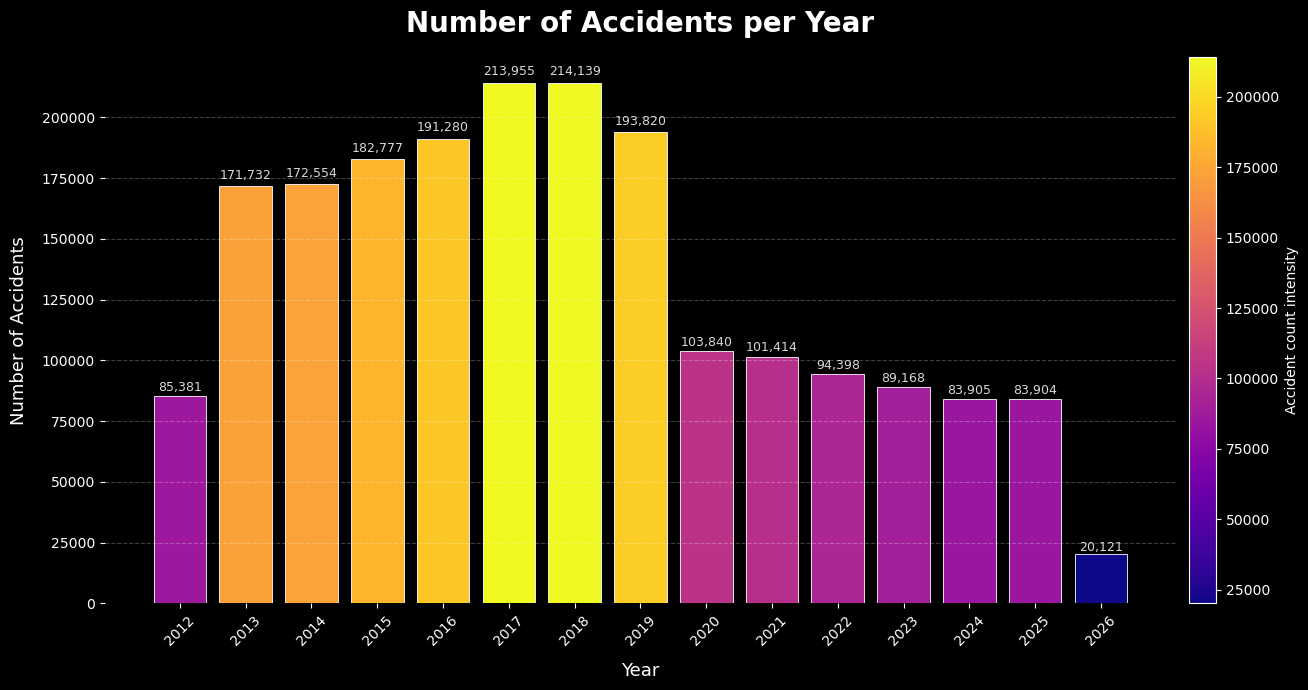

In [94]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import Normalize

year_counts = df["CRASH DATETIME"].dt.year.value_counts().sort_index()

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 7))

    norm = Normalize(vmin=year_counts.min(), vmax=year_counts.max())
    cmap = matplotlib.colormaps.get_cmap("plasma")
    colors = [cmap(norm(v)) for v in year_counts.values]

    bars = ax.bar(
        year_counts.index.astype(str),
        year_counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )

    # value labels on top of bars
    for bar, value in zip(bars, year_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="white",
            alpha=0.85,
        )

    ax.set_title(
        "Number of Accidents per Year",
        fontsize=20,
        fontweight="bold",
        pad=18,
        color="white",
    )
    ax.set_xlabel("Year", fontsize=13, labelpad=10)
    ax.set_ylabel("Number of Accidents", fontsize=13, labelpad=10)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)

    # colorbar acting as a legend for intensity
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Accident count intensity", color="white")

    plt.tight_layout()
    plt.show()

Visible change in 2020, probably due to pandemic and therefore reduced traffic. Interestingly, the number of collisions did not pick up again after the pandemic. 

The number for 2012 is not representative, as we have data only from 1st of July 2012.

## What month has the most accidents?

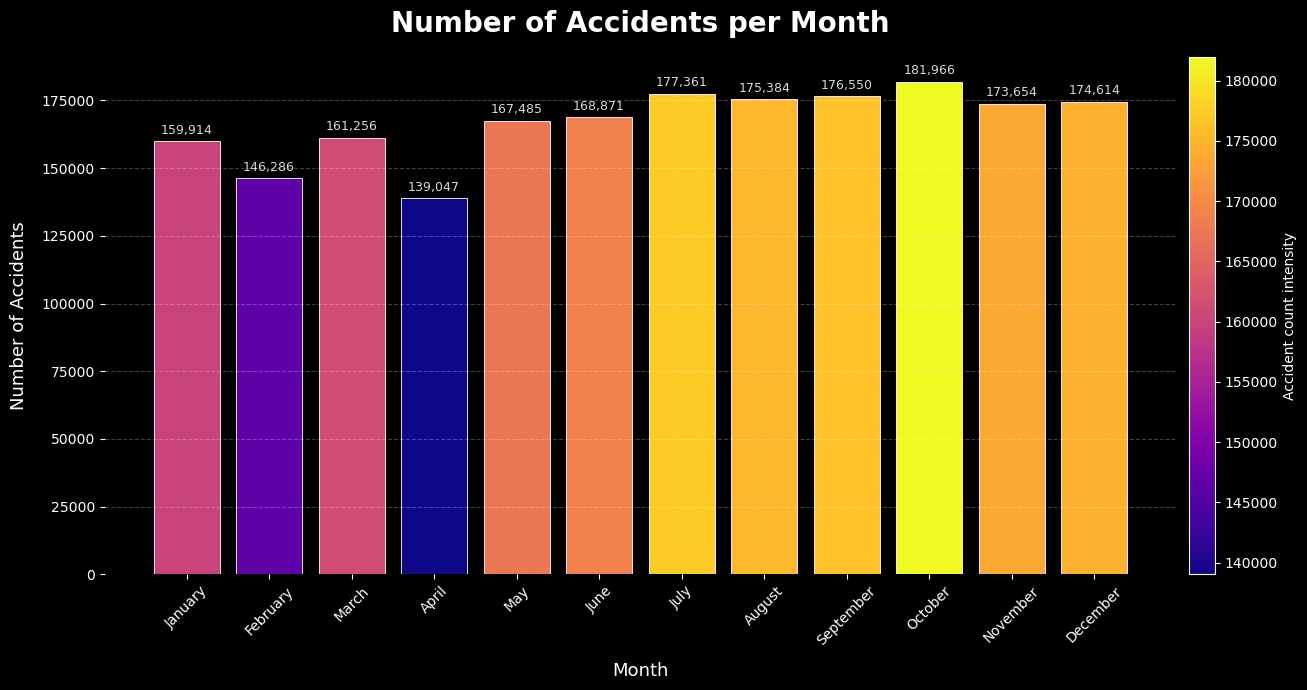

In [95]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import Normalize

month_counts = df["CRASH DATETIME"].dt.month.value_counts().sort_index()
month_counts.index = month_counts.index.map(
    {
        1: "January",
        2: "February",
        3: "March",
        4: "April",
        5: "May",
        6: "June",
        7: "July",
        8: "August",
        9: "September",
        10: "October",
        11: "November",
        12: "December",
    }
)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 7))

    norm = Normalize(vmin=month_counts.min(), vmax=month_counts.max())
    cmap = matplotlib.colormaps.get_cmap("plasma")
    colors = [cmap(norm(v)) for v in month_counts.values]

    bars = ax.bar(
        month_counts.index.astype(str),
        month_counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )

    for bar, value in zip(bars, month_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="white",
            alpha=0.85,
        )

    ax.set_title(
        "Number of Accidents per Month",
        fontsize=20,
        fontweight="bold",
        pad=18,
        color="white",
    )
    ax.set_xlabel("Month", fontsize=13, labelpad=10)
    ax.set_ylabel("Number of Accidents", fontsize=13, labelpad=10)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Accident count intensity", color="white")

    plt.tight_layout()
    plt.show()

In [96]:
month_counts = df["CRASH DATETIME"].dt.month.value_counts()
month_counts

CRASH DATETIME
10    181966
7     177361
9     176550
8     175384
12    174614
11    173654
6     168871
5     167485
3     161256
1     159914
2     146286
4     139047
Name: count, dtype: int64

## When in a month do collisions happen?

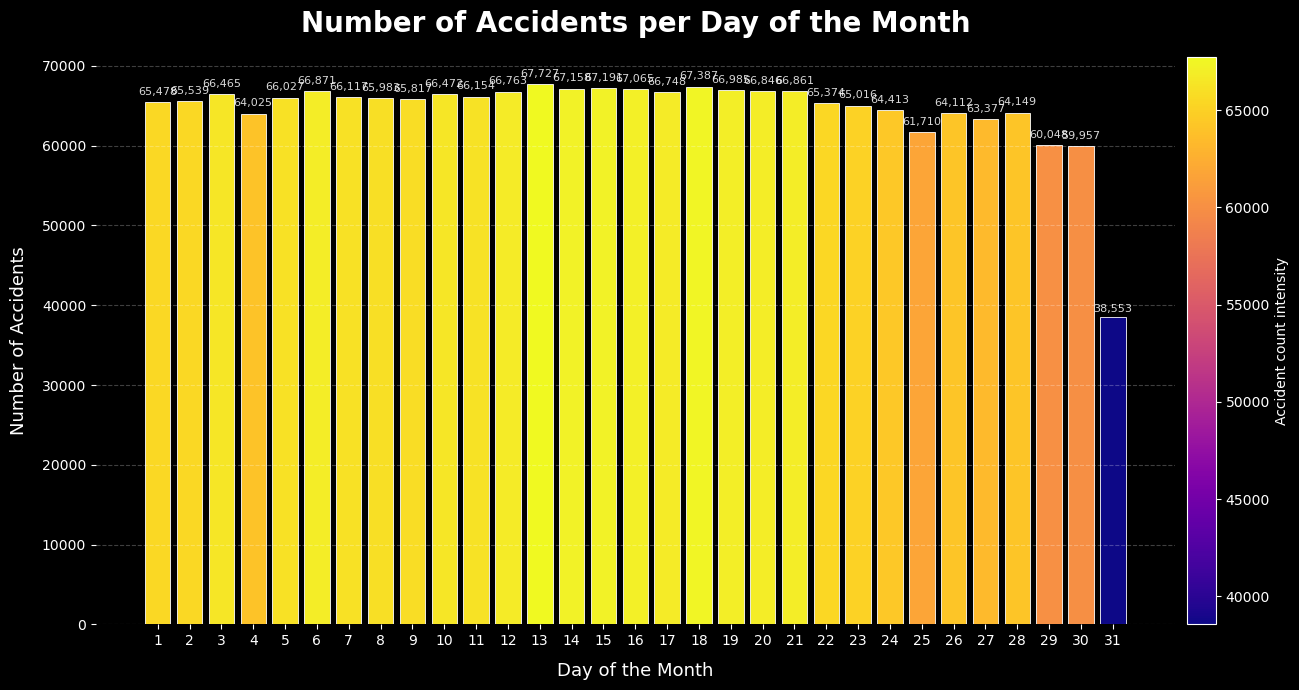

In [97]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import Normalize

day_counts = df["CRASH DATETIME"].dt.day.value_counts().sort_index()

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 7))

    norm = Normalize(vmin=day_counts.min(), vmax=day_counts.max())
    cmap = matplotlib.colormaps.get_cmap("plasma")
    colors = [cmap(norm(v)) for v in day_counts.values]

    bars = ax.bar(
        day_counts.index.astype(str),
        day_counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )

    for bar, value in zip(bars, day_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="white",
            alpha=0.85,
        )

    ax.set_title(
        "Number of Accidents per Day of the Month",
        fontsize=20,
        fontweight="bold",
        pad=18,
        color="white",
    )
    ax.set_xlabel("Day of the Month", fontsize=13, labelpad=10)
    ax.set_ylabel("Number of Accidents", fontsize=13, labelpad=10)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Accident count intensity", color="white")

    plt.tight_layout()
    plt.show()

Nothing stands out, as data for 31st day of a month is recorded for half of the months.

## When in a week do the collisions happen?

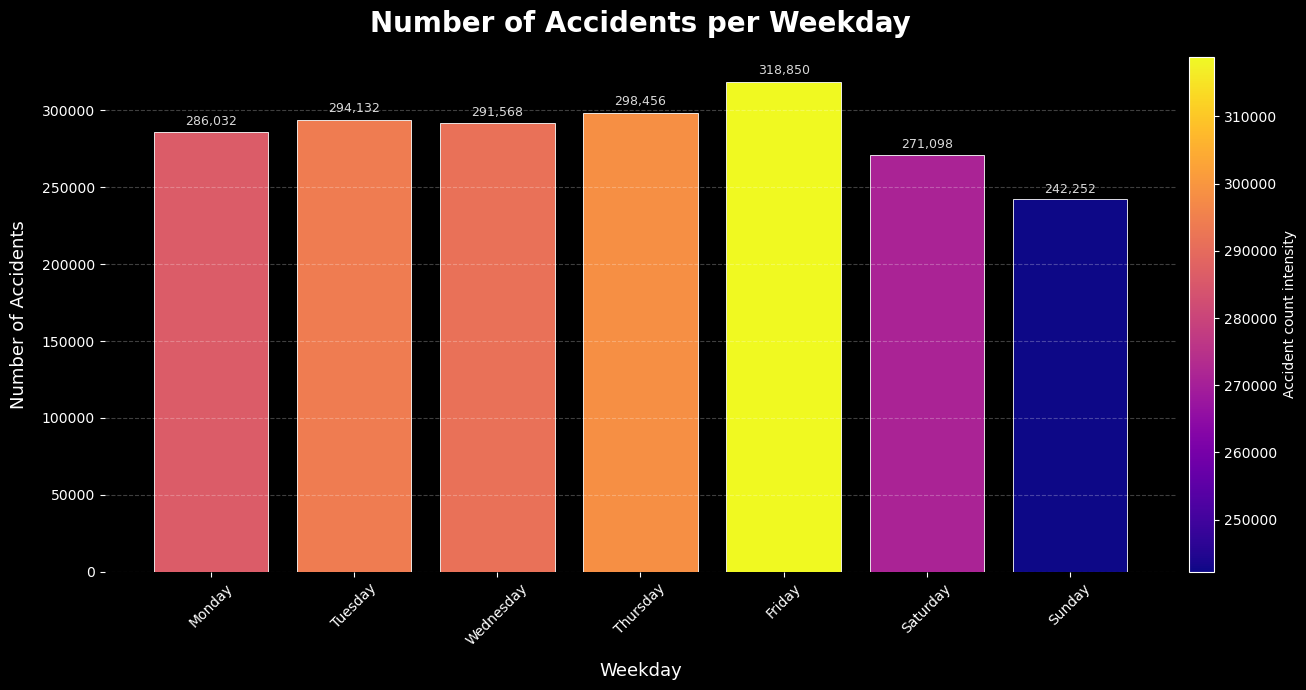

In [98]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import Normalize

weekday_counts = (
    df["CRASH DATETIME"].dt.weekday.value_counts().sort_index()
)
weekday_counts.index = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 7))

    norm = Normalize(vmin=weekday_counts.min(), vmax=weekday_counts.max())
    cmap = matplotlib.colormaps.get_cmap("plasma")
    colors = [cmap(norm(v)) for v in weekday_counts.values]

    bars = ax.bar(
        weekday_counts.index.astype(str),
        weekday_counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )

    for bar, value in zip(bars, weekday_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="white",
            alpha=0.85,
        )

    ax.set_title(
        "Number of Accidents per Weekday",
        fontsize=20,
        fontweight="bold",
        pad=18,
        color="white",
    )
    ax.set_xlabel("Weekday", fontsize=13, labelpad=10)
    ax.set_ylabel("Number of Accidents", fontsize=13, labelpad=10)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Accident count intensity", color="white")

    plt.tight_layout()
    plt.show()

## Did the weekly distribution change after pandemic?

We will consider the period from 2012 to 2019 as "before pandemic" and the period from 2020 to 2024 as "after pandemic". We will create two separate dataframes for these periods and then plot the weekly distribution of accidents for each period.

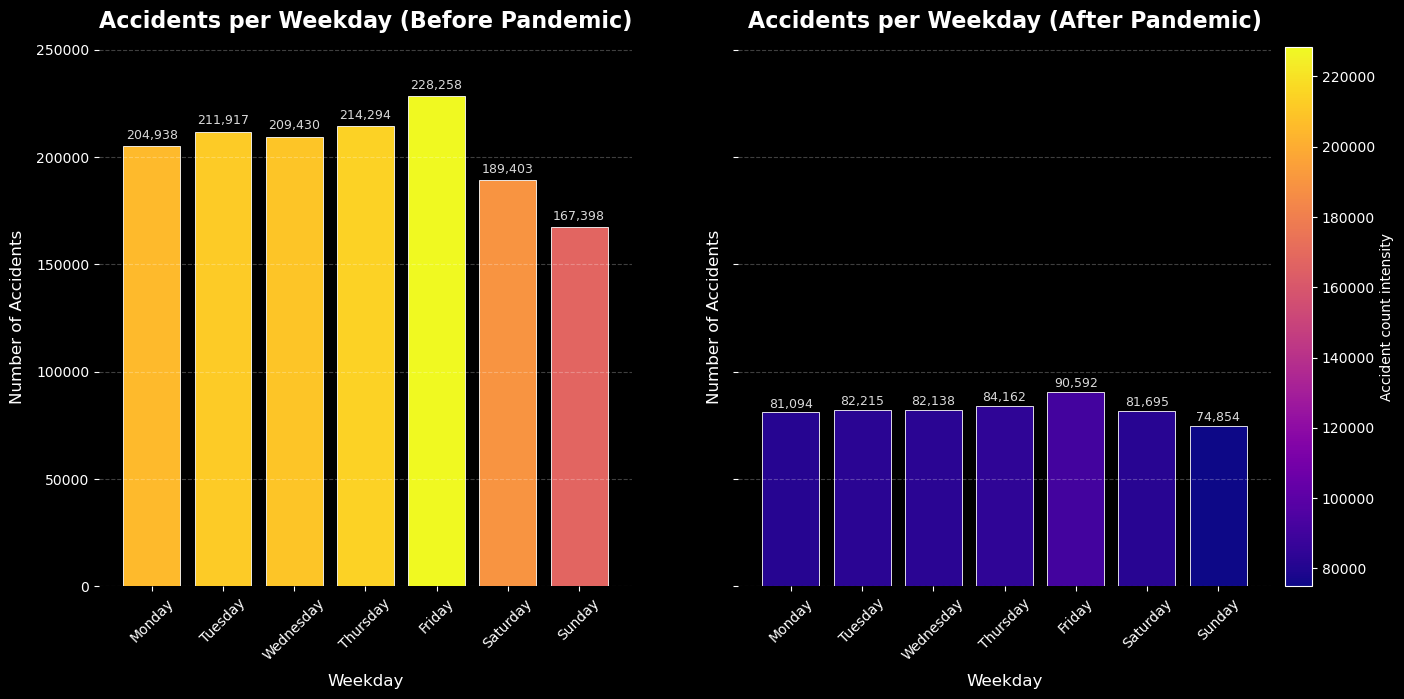

In [99]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import Normalize

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

year = df["CRASH DATETIME"].dt.year
weekday = df["CRASH DATETIME"].dt.weekday

weekday_counts_before = weekday[year < 2020].value_counts().sort_index()
weekday_counts_before.index = weekday_order
weekday_counts_after = weekday[year >= 2020].value_counts().sort_index()
weekday_counts_after.index = weekday_order

y_max = max(weekday_counts_before.max(), weekday_counts_after.max()) * 1.1
v_min = min(weekday_counts_before.min(), weekday_counts_after.min())
v_max = max(weekday_counts_before.max(), weekday_counts_after.max())

cmap = matplotlib.colormaps.get_cmap("plasma")
norm = Normalize(vmin=v_min, vmax=v_max)


def _plot_weekday(ax, counts, title):
    colors = [cmap(norm(v)) for v in counts.values]
    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )
    for bar, value in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="white",
            alpha=0.85,
        )
    ax.set_title(title, fontsize=16, fontweight="bold", pad=14, color="white")
    ax.set_xlabel("Weekday", fontsize=12, labelpad=8)
    ax.set_ylabel("Number of Accidents", fontsize=12, labelpad=8)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, y_max)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)


with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    _plot_weekday(axes[0], weekday_counts_before, "Accidents per Weekday (Before Pandemic)")
    _plot_weekday(axes[1], weekday_counts_after, "Accidents per Weekday (After Pandemic)")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.01)
    cbar.set_label("Accident count intensity", color="white")

    plt.show()

## What time of day does crashes occur the most ? 

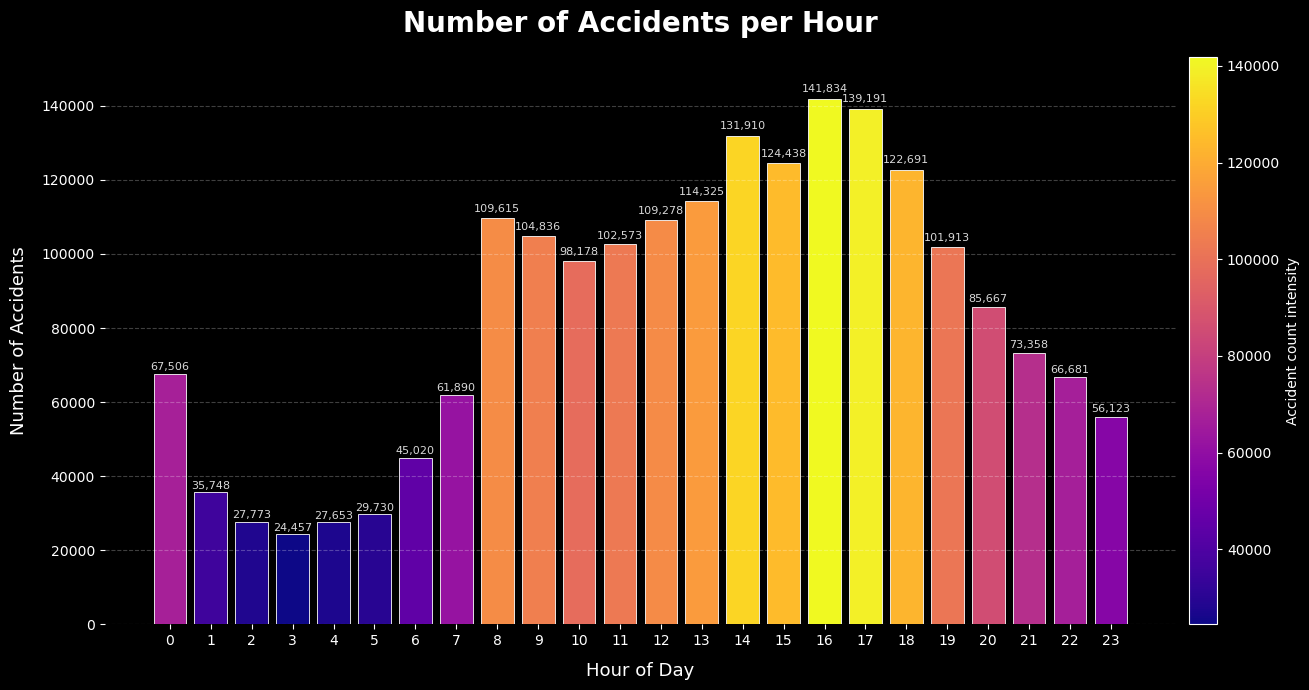

In [100]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import Normalize

hour_counts = df["CRASH DATETIME"].dt.hour.value_counts().sort_index()

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 7))

    norm = Normalize(vmin=hour_counts.min(), vmax=hour_counts.max())
    cmap = matplotlib.colormaps.get_cmap("plasma")
    colors = [cmap(norm(v)) for v in hour_counts.values]

    bars = ax.bar(
        hour_counts.index.astype(str),
        hour_counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )

    for bar, value in zip(bars, hour_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="white",
            alpha=0.85,
        )

    ax.set_title(
        "Number of Accidents per Hour",
        fontsize=20,
        fontweight="bold",
        pad=18,
        color="white",
    )
    ax.set_xlabel("Hour of Day", fontsize=13, labelpad=10)
    ax.set_ylabel("Number of Accidents", fontsize=13, labelpad=10)
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, hour_counts.max() * 1.08)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Accident count intensity", color="white")

    plt.tight_layout()
    plt.show()

Most collisions happen during the day, when the traffic is dense. 

## Did hourly distribution change after pandemic?

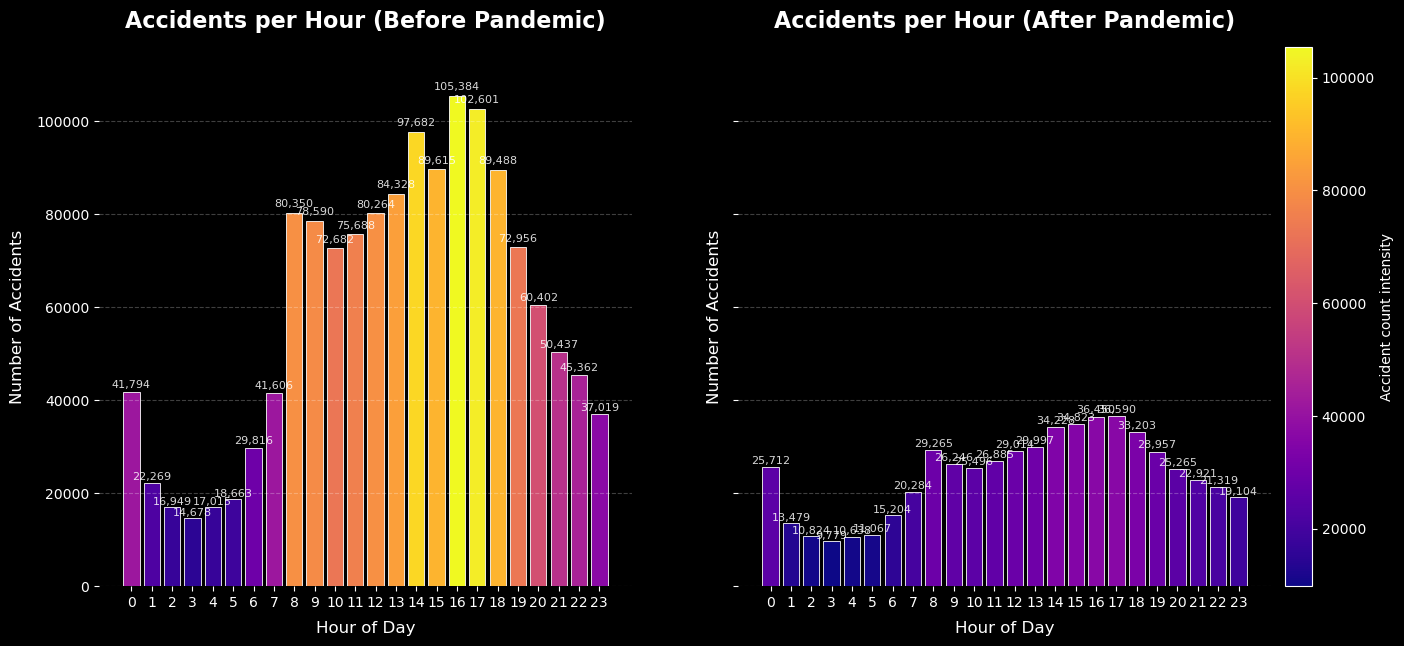

In [101]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import Normalize

year = df["CRASH DATETIME"].dt.year
hour = df["CRASH DATETIME"].dt.hour

hour_counts_before = hour[year < 2020].value_counts().sort_index()
hour_counts_after = hour[year >= 2020].value_counts().sort_index()

y_max = max(hour_counts_before.max(), hour_counts_after.max()) * 1.1
v_min = min(hour_counts_before.min(), hour_counts_after.min())
v_max = max(hour_counts_before.max(), hour_counts_after.max())

cmap = matplotlib.colormaps.get_cmap("plasma")
norm = Normalize(vmin=v_min, vmax=v_max)


def _plot_hour(ax, counts, title):
    colors = [cmap(norm(v)) for v in counts.values]
    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )
    for bar, value in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="white",
            alpha=0.85,
        )
    ax.set_title(title, fontsize=16, fontweight="bold", pad=14, color="white")
    ax.set_xlabel("Hour of Day", fontsize=12, labelpad=8)
    ax.set_ylabel("Number of Accidents", fontsize=12, labelpad=8)
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, y_max)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)


with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    _plot_hour(axes[0], hour_counts_before, "Accidents per Hour (Before Pandemic)")
    _plot_hour(axes[1], hour_counts_after, "Accidents per Hour (After Pandemic)")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.01)
    cbar.set_label("Accident count intensity", color="white")

    plt.show()

## Did the number of serious accidents also drop after pandemic?

In [102]:
df_clean["NUMBER OF PERSONS INJURED"].nunique()

NameError: name 'df_clean' is not defined

In [ ]:
df_clean["NUMBER OF PERSONS KILLED"].nunique()

7

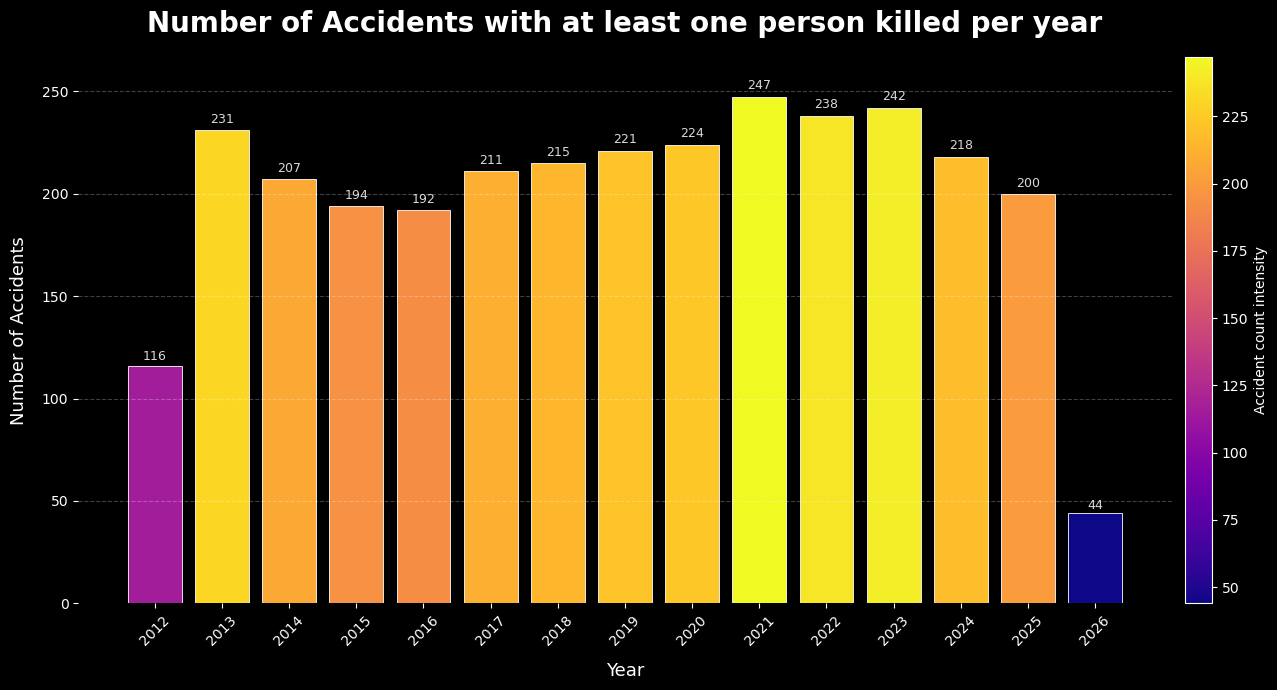

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import Normalize

df_killed = df[df["NUMBER OF PERSONS KILLED"] > 0]
killed_year_counts = df_killed["CRASH DATETIME"].dt.year.value_counts().sort_index()

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 7))

    norm = Normalize(vmin=killed_year_counts.min(), vmax=killed_year_counts.max())
    cmap = matplotlib.colormaps.get_cmap("plasma")
    colors = [cmap(norm(v)) for v in killed_year_counts.values]

    bars = ax.bar(
        killed_year_counts.index.astype(str),
        killed_year_counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )

    for bar, value in zip(bars, killed_year_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="white",
            alpha=0.85,
        )

    ax.set_title(
        "Number of Accidents with at least one person killed per year",
        fontsize=20,
        fontweight="bold",
        pad=18,
        color="white",
    )
    ax.set_xlabel("Year", fontsize=13, labelpad=10)
    ax.set_ylabel("Number of Accidents", fontsize=13, labelpad=10)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, killed_year_counts.max() * 1.08)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Accident count intensity", color="white")

    plt.tight_layout()
    plt.show()

## When in a day do the more serious accidents happen?

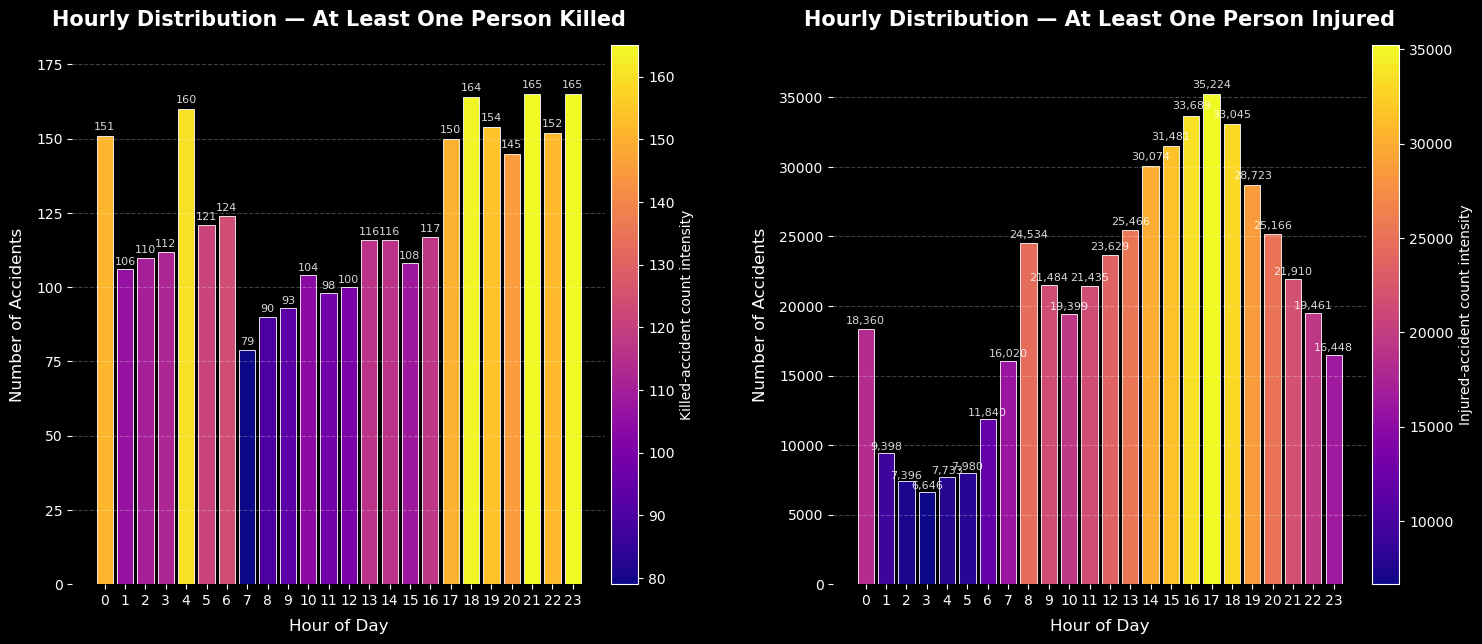

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import Normalize

hour = df["CRASH DATETIME"].dt.hour
hourly_killed_counts = hour[df["NUMBER OF PERSONS KILLED"] > 0].value_counts().sort_index()
hourly_injured_counts = hour[df["NUMBER OF PERSONS INJURED"] > 0].value_counts().sort_index()

cmap = matplotlib.colormaps.get_cmap("plasma")


def _plot_hour(ax, counts, title):
    norm = Normalize(vmin=counts.min(), vmax=counts.max())
    colors = [cmap(norm(v)) for v in counts.values]
    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )
    for bar, value in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=8,
            color="white",
            alpha=0.85,
        )
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14, color="white")
    ax.set_xlabel("Hour of Day", fontsize=12, labelpad=8)
    ax.set_ylabel("Number of Accidents", fontsize=12, labelpad=8)
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, counts.max() * 1.1)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)
    return norm


with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    norm_k = _plot_hour(axes[0], hourly_killed_counts, "Hourly Distribution — At Least One Person Killed")
    norm_i = _plot_hour(axes[1], hourly_injured_counts, "Hourly Distribution — At Least One Person Injured")

    sm_k = cm.ScalarMappable(cmap=cmap, norm=norm_k); sm_k.set_array([])
    fig.colorbar(sm_k, ax=axes[0], pad=0.01).set_label("Killed-accident count intensity", color="white")
    sm_i = cm.ScalarMappable(cmap=cmap, norm=norm_i); sm_i.set_array([])
    fig.colorbar(sm_i, ax=axes[1], pad=0.01).set_label("Injured-accident count intensity", color="white")

    plt.show()

## What are the most common contributing factors?

We combine contributing factors for all vehicles, leave out Unspecified and plot the values on a log scale axis for better visualization.

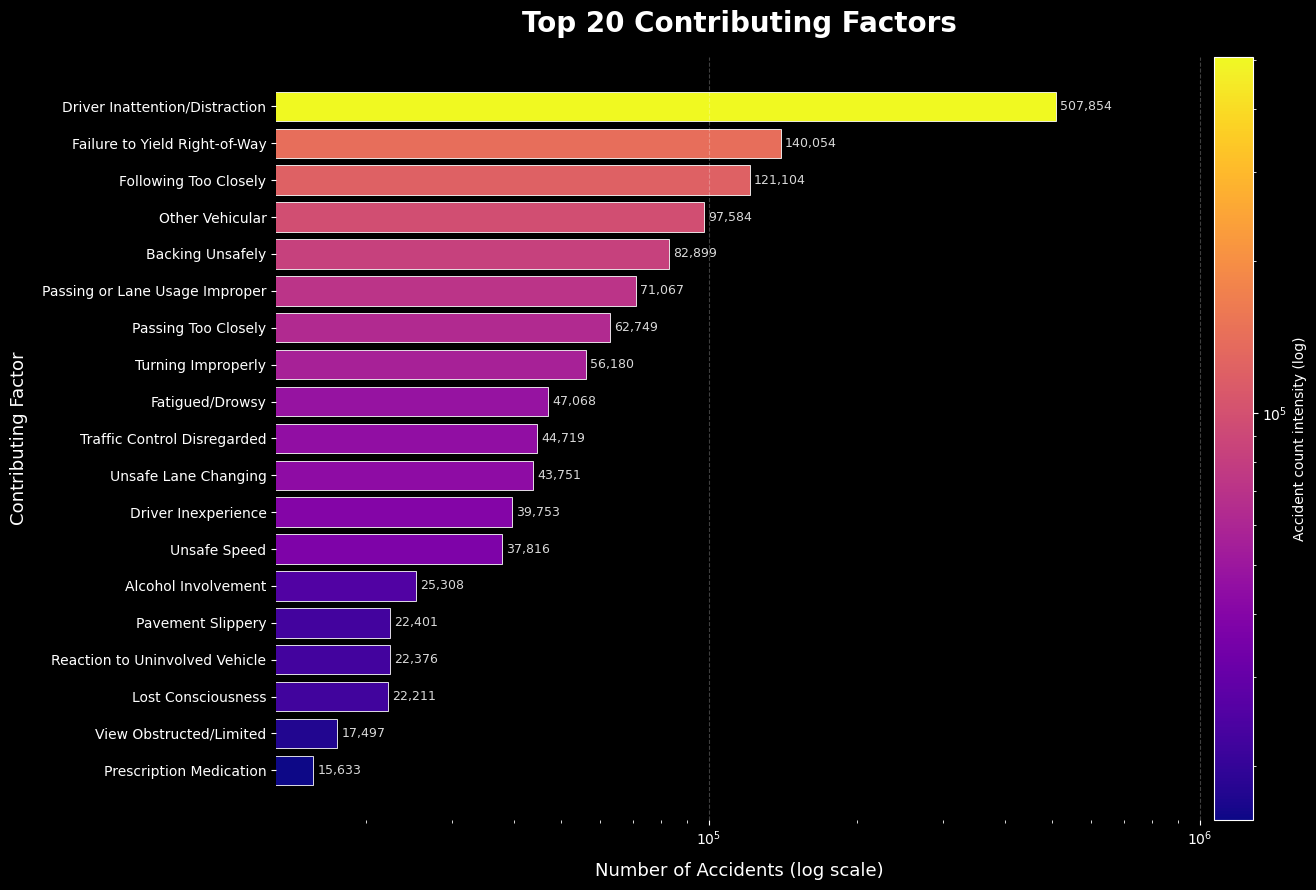

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import LogNorm

contributing_factors = pd.concat(
    [
        df["CONTRIBUTING FACTOR VEHICLE 1"],
        df["CONTRIBUTING FACTOR VEHICLE 2"],
        df["CONTRIBUTING FACTOR VEHICLE 3"],
        df["CONTRIBUTING FACTOR VEHICLE 4"],
        df["CONTRIBUTING FACTOR VEHICLE 5"],
    ]
)
factor_counts = contributing_factors.value_counts().head(20).drop("Unspecified")
factor_counts = factor_counts.sort_values(ascending=True)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 9))

    norm = LogNorm(vmin=factor_counts.min(), vmax=factor_counts.max())
    cmap = matplotlib.colormaps.get_cmap("plasma")
    colors = [cmap(norm(v)) for v in factor_counts.values]

    bars = ax.barh(
        factor_counts.index.astype(str),
        factor_counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )

    for bar, value in zip(bars, factor_counts.values):
        ax.text(
            bar.get_width() * 1.02,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}",
            ha="left",
            va="center",
            fontsize=9,
            color="white",
            alpha=0.85,
        )

    ax.set_xscale("log")
    ax.set_xlim(right=factor_counts.max() * 2.0)
    ax.set_title(
        "Top 20 Contributing Factors",
        fontsize=20,
        fontweight="bold",
        pad=18,
        color="white",
    )
    ax.set_xlabel("Number of Accidents (log scale)", fontsize=13, labelpad=10)
    ax.set_ylabel("Contributing Factor", fontsize=13, labelpad=10)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Accident count intensity (log)", color="white")

    plt.tight_layout()
    plt.show()

## Did the contributing factors change after pandemic?

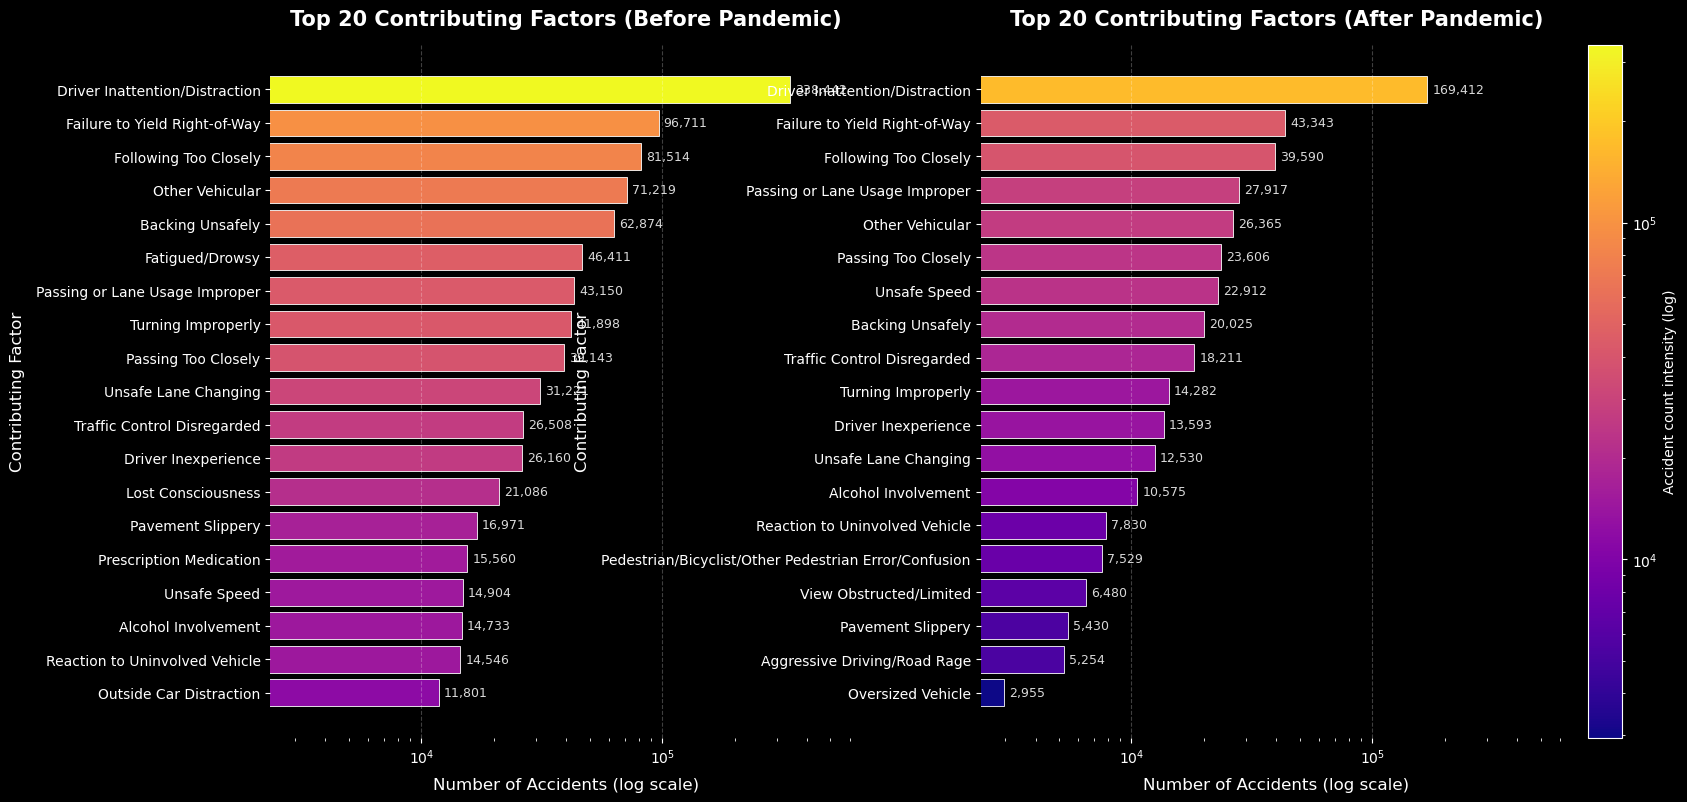

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import cm
from matplotlib.colors import LogNorm

factor_cols = [f"CONTRIBUTING FACTOR VEHICLE {i}" for i in range(1, 6)]
year = df["CRASH DATETIME"].dt.year

df_before = df[year < 2020]
df_after = df[year >= 2020]

contributing_factors_before = pd.concat([df_before[c] for c in factor_cols])
contributing_factors_after = pd.concat([df_after[c] for c in factor_cols])

factor_counts_before = (
    contributing_factors_before.value_counts().head(20).drop("Unspecified", errors="ignore").sort_values(ascending=True)
)
factor_counts_after = (
    contributing_factors_after.value_counts().head(20).drop("Unspecified", errors="ignore").sort_values(ascending=True)
)

v_min = min(factor_counts_before.min(), factor_counts_after.min())
v_max = max(factor_counts_before.max(), factor_counts_after.max())
x_max = v_max * 2.0

cmap = matplotlib.colormaps.get_cmap("plasma")
norm = LogNorm(vmin=v_min, vmax=v_max)


def _plot_factors(ax, counts, title):
    colors = [cmap(norm(v)) for v in counts.values]
    bars = ax.barh(
        counts.index.astype(str),
        counts.values,
        color=colors,
        edgecolor="white",
        linewidth=0.6,
    )
    for bar, value in zip(bars, counts.values):
        ax.text(
            bar.get_width() * 1.05,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}",
            ha="left",
            va="center",
            fontsize=9,
            color="white",
            alpha=0.85,
        )
    ax.set_xscale("log")
    ax.set_xlim(left=v_min * 0.8, right=x_max)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14, color="white")
    ax.set_xlabel("Number of Accidents (log scale)", fontsize=12, labelpad=8)
    ax.set_ylabel("Contributing Factor", fontsize=12, labelpad=8)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    sns.despine(ax=ax, left=True, bottom=True)


with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))

    _plot_factors(axes[0], factor_counts_before, "Top 20 Contributing Factors (Before Pandemic)")
    _plot_factors(axes[1], factor_counts_after, "Top 20 Contributing Factors (After Pandemic)")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.01)
    cbar.set_label("Accident count intensity (log)", color="white")

    plt.show()

## Do some zipcodes have more crashes ? 

# <span style="color: red;">I removed zipcodes but we could use BUROUGHS ? </span>

In [ ]:
# Iterate over all values in zipcode columns and identify their types, only print unique types
unique_zipcode_types = DF["ZIP CODE"].apply(type).unique()
print(unique_zipcode_types)

KeyError: 'ZIP CODE'

<Axes: title={'center': 'Number of Accidents per Zipcode'}, xlabel='Zipcode', ylabel='Number of Accidents'>

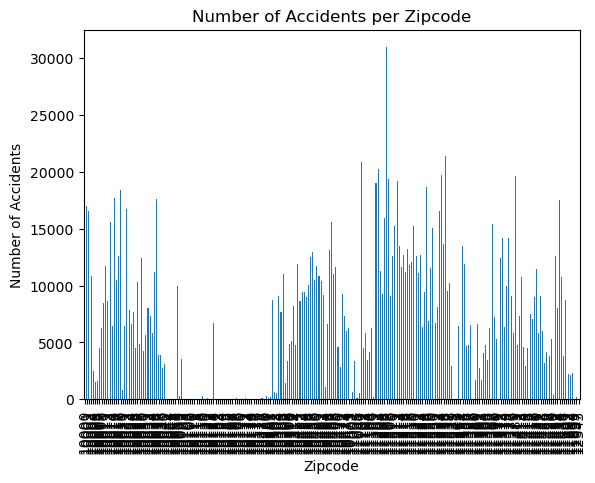

In [ ]:
# What zipcode has the most accidents? We use the column "ZIP CODE" to count the number of accidents for each zipcode, create a bar plot comparing each zipcode
DF["ZIP CODE"] = (
    DF["ZIP CODE"]
    .astype(str)  # convert everything to string first
    .str.strip()  # remove whitespace
    .replace("", float("nan"))  # turn empty strings into NaN
    .dropna()  # drop NaNs
    .astype(float)  # normalize "10001.0" strings
    .astype(int)  # drop the decimal
    .astype(str)  # convert to string
    .str.zfill(5)  # restore leading zeros
)
zipcode_counts = DF["ZIP CODE"].dropna().value_counts().sort_index()
zipcode_counts.plot(
    kind="bar",
    title="Number of Accidents per Zipcode",
    xlabel="Zipcode",
    ylabel="Number of Accidents",
)

## Did vision zero mitigate crashes and/or fatalities? 

## When are crashes most deadly vs. most frequent?

## Which cross sections are most deadly ??

## Are some car owners more deadly than others ? Does it that say more about the car or the person ? 

## When does the most violent crashes occur (meaning more people die or not only injured) ?